In [42]:
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from grid2op.PlotGrid import PlotMatplot
from lightsim2grid import LightSimBackend

In [1]:
import os
import grid2op as gp

In [2]:
gp.list_available_local_env()

['rte_case14_realistic',
 'l2rpn_case14_sandbox',
 'rte_case14_redisp',
 'l2rpn_neurips_2020_track1_small']

In [108]:
plot_helper = PlotMatplot(env.observation_space)

In [20]:
from grid2op.Agent import DoNothingAgent, TopologyGreedy, GreedyAgent, RandomAgent

In [15]:
# Use LightSim2Grid backend
backend = LightSimBackend()

In [200]:
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
env.reset()

In [187]:
env.chronics_handler.subpaths[:10]

array(['/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_000',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_001',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_002',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_003',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_004',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_005',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_006',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_007',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_008',
       '/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_009'],
      dtype='<U86')

In [188]:
len(env.chronics_handler.subpaths)

576

In [194]:
env.chronics_handler.get_id()

'/home/dai/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_000'

In [196]:
env.chronics_handler.max_timestep()

8062

In [204]:
env.chronics_handler.data

In [205]:
env.chronics_handler.data.prod_p

array([[  0. ,  25.3,   0. , ..., 399. ,   0. ,  27.7],
       [  0. ,  24.6,   0. , ..., 399. ,   0. ,  27.6],
       [  0. ,  24.6,   0. , ..., 399. ,   0. ,  27.6],
       ...,
       [  0. ,  26.6,   0. , ..., 399. ,   0. ,  36. ],
       [  0. ,  26.5,   0. , ..., 399. ,   0. ,  37.2],
       [  0. ,  26.9,   0. , ..., 399. ,   0. ,  36.6]], dtype=float32)

In [206]:
env.chronics_handler.data.prod_p.shape

(8063, 22)

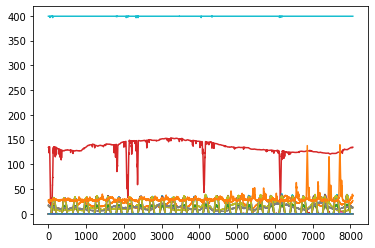

In [208]:
plot(env.chronics_handler.data.prod_p)

In [209]:
print(env.chronics_handler.data.load_p.shape)
env.chronics_handler.data.load_p

(8063, 37)


array([[ 12.  ,  -1.14,   5.12, ...,  24.  , -24.87, -26.94],
       [ 11.8 ,  -0.29,   5.8 , ...,  23.25, -24.12, -27.29],
       [ 11.3 ,  -0.63,   5.33, ...,  24.73, -23.35, -29.16],
       ...,
       [ 13.5 ,  -7.2 ,   0.43, ...,   4.12, -21.92, -19.69],
       [ 14.  ,  -7.79,   0.11, ...,   4.69, -21.7 , -19.72],
       [ 13.5 ,  -6.59,   1.02, ...,   3.27, -21.35, -19.68]],
      dtype=float32)

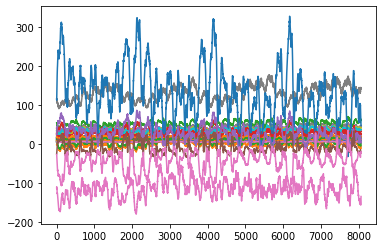

In [210]:
plot(env.chronics_handler.data.load_p)

In [215]:
env.chronics_handler.data.maintenance.shape

(8063, 59)

In [222]:
handler = env.chronics_handler
n = len(handler.subpaths)
env.set_id(0)
for i in range(n):
    env.reset()
    print(handler.get_name(), handler.max_timestep(), handler.data.current_datetime)

Scenario_april_000 8062 2012-04-01 00:05:00
Scenario_april_001 8062 2012-04-01 00:05:00
Scenario_april_002 8062 2012-04-01 00:05:00
Scenario_april_003 8062 2012-04-01 00:05:00
Scenario_april_004 8062 2012-04-01 00:05:00
Scenario_april_005 8062 2012-04-01 00:05:00
Scenario_april_006 8062 2012-04-01 00:05:00
Scenario_april_007 8062 2012-04-01 00:05:00
Scenario_april_008 8062 2012-04-01 00:05:00
Scenario_april_009 8062 2012-04-01 00:05:00
Scenario_april_010 8062 2012-04-01 00:05:00
Scenario_april_011 8062 2012-04-01 00:05:00
Scenario_april_012 8062 2012-04-01 00:05:00
Scenario_april_013 8062 2012-04-01 00:05:00
Scenario_april_014 8062 2012-04-01 00:05:00
Scenario_april_015 8062 2012-04-01 00:05:00
Scenario_april_016 8062 2012-04-01 00:05:00
Scenario_april_017 8062 2012-04-01 00:05:00
Scenario_april_018 8062 2012-04-01 00:05:00
Scenario_april_019 8062 2012-04-01 00:05:00
Scenario_april_020 8062 2012-04-01 00:05:00
Scenario_april_021 8062 2012-04-01 00:05:00
Scenario_april_022 8062 2012-04-

Scenario_february_036 8062 2012-02-01 00:05:00
Scenario_february_037 8062 2012-02-01 00:05:00
Scenario_february_038 8062 2012-02-01 00:05:00
Scenario_february_039 8062 2012-02-01 00:05:00
Scenario_february_040 8062 2012-02-01 00:05:00
Scenario_february_041 8062 2012-02-01 00:05:00
Scenario_february_042 8062 2012-02-01 00:05:00
Scenario_february_043 8062 2012-02-01 00:05:00
Scenario_february_044 8062 2012-02-01 00:05:00
Scenario_february_045 8062 2012-02-01 00:05:00
Scenario_february_046 8062 2012-02-01 00:05:00
Scenario_february_047 8062 2012-02-01 00:05:00
Scenario_january_000 8062 2012-01-01 00:05:00
Scenario_january_001 8062 2012-01-01 00:05:00
Scenario_january_002 8062 2012-01-01 00:05:00
Scenario_january_003 8062 2012-01-01 00:05:00
Scenario_january_004 8062 2012-01-01 00:05:00
Scenario_january_005 8062 2012-01-01 00:05:00
Scenario_january_006 8062 2012-01-01 00:05:00
Scenario_january_007 8062 2012-01-01 00:05:00
Scenario_january_008 8062 2012-01-01 00:05:00
Scenario_january_009 8

Scenario_march_030 8062 2012-03-01 00:05:00
Scenario_march_031 8062 2012-03-01 00:05:00
Scenario_march_032 8062 2012-03-01 00:05:00
Scenario_march_033 8062 2012-03-01 00:05:00
Scenario_march_034 8062 2012-03-01 00:05:00
Scenario_march_035 8062 2012-03-01 00:05:00
Scenario_march_036 8062 2012-03-01 00:05:00
Scenario_march_037 8062 2012-03-01 00:05:00
Scenario_march_038 8062 2012-03-01 00:05:00
Scenario_march_039 8062 2012-03-01 00:05:00
Scenario_march_040 8062 2012-03-01 00:05:00
Scenario_march_041 8062 2012-03-01 00:05:00
Scenario_march_042 8062 2012-03-01 00:05:00
Scenario_march_043 8062 2012-03-01 00:05:00
Scenario_march_044 8062 2012-03-01 00:05:00
Scenario_march_045 8062 2012-03-01 00:05:00
Scenario_march_046 8062 2012-03-01 00:05:00
Scenario_march_047 8062 2012-03-01 00:05:00
Scenario_may_000 8062 2012-05-01 00:05:00
Scenario_may_001 8062 2012-05-01 00:05:00
Scenario_may_002 8062 2012-05-01 00:05:00
Scenario_may_003 8062 2012-05-01 00:05:00
Scenario_may_004 8062 2012-05-01 00:05:0

Scenario_september_020 8062 2012-09-01 00:05:00
Scenario_september_021 8062 2012-09-01 00:05:00
Scenario_september_022 8062 2012-09-01 00:05:00
Scenario_september_023 8062 2012-09-01 00:05:00
Scenario_september_024 8062 2012-09-01 00:05:00
Scenario_september_025 8062 2012-09-01 00:05:00
Scenario_september_026 8062 2012-09-01 00:05:00
Scenario_september_027 8062 2012-09-01 00:05:00
Scenario_september_028 8062 2012-09-01 00:05:00
Scenario_september_029 8062 2012-09-01 00:05:00
Scenario_september_030 8062 2012-09-01 00:05:00
Scenario_september_031 8062 2012-09-01 00:05:00
Scenario_september_032 8062 2012-09-01 00:05:00
Scenario_september_033 8062 2012-09-01 00:05:00
Scenario_september_034 8062 2012-09-01 00:05:00
Scenario_september_035 8062 2012-09-01 00:05:00
Scenario_september_036 8062 2012-09-01 00:05:00
Scenario_september_037 8062 2012-09-01 00:05:00
Scenario_september_038 8062 2012-09-01 00:05:00
Scenario_september_039 8062 2012-09-01 00:05:00
Scenario_september_040 8062 2012-09-01 0

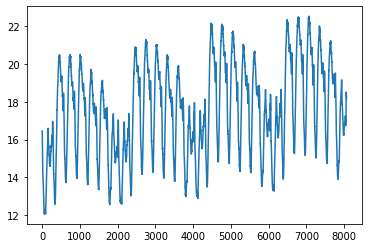

In [263]:
# Mean load
env.set_id(0)
mean = zeros(8063)
for i in range(48):
    env.reset()
    mean += handler.data.load_p[:, 10] / 48
plot(mean)

(0.0, 2.0575734071784257)

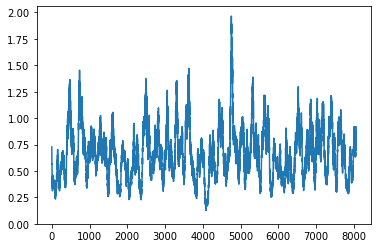

In [269]:
# Variance load
env.set_id(0)
var = zeros(8063)
for i in range(48):
    env.reset()
    var += square(handler.data.load_p[:, 10] - mean) / 48
plot(var)
ylim(0)

In [275]:
env.grid_objects_types

array([[ 0, -1, -1,  2, -1],
       [ 0,  0, -1, -1, -1],
       [ 0,  1, -1, -1, -1],
       [ 1, -1, -1,  3, -1],
       [ 1, -1, -1,  4, -1],
       [ 1, -1, -1, 12, -1],
       [ 1, -1,  0, -1, -1],
       [ 1,  2, -1, -1, -1],
       [ 1,  3, -1, -1, -1],
       [ 2, -1, -1,  0, -1],
       [ 2, -1, -1,  1, -1],
       [ 2,  4, -1, -1, -1],
       [ 3, -1, -1, -1,  0],
       [ 3, -1, -1, -1,  3],
       [ 3,  5, -1, -1, -1],
       [ 4, -1, -1, -1,  1],
       [ 4, -1, -1, -1,  2],
       [ 4, -1, -1, -1,  4],
       [ 4, -1, -1,  5, -1],
       [ 4, -1, -1,  6, -1],
       [ 4, -1, -1, -1, 55],
       [ 5, -1, -1, 46, -1],
       [ 5, -1, -1, 55, -1],
       [ 5,  6, -1, -1, -1],
       [ 6, -1, -1, -1,  5],
       [ 6, -1, -1,  7, -1],
       [ 6,  7, -1, -1, -1],
       [ 7, -1, -1, -1,  6],
       [ 7, -1, -1, -1,  7],
       [ 7, -1, -1,  8, -1],
       [ 7, -1, -1,  9, -1],
       [ 7, -1,  1, -1, -1],
       [ 7,  8, -1, -1, -1],
       [ 8, -1, -1, -1,  8],
       [ 8, -1

In [248]:
env.gen_type

array(['thermal', 'wind', 'thermal', 'hydro', 'thermal', 'wind', 'solar',
       'solar', 'wind', 'solar', 'thermal', 'solar', 'solar', 'thermal',
       'solar', 'solar', 'thermal', 'wind', 'solar', 'nuclear', 'thermal',
       'thermal'], dtype='<U10')

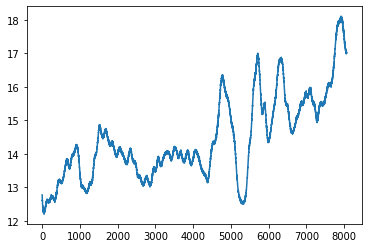

In [270]:
# Mean prod wind
env.set_id(0)
mean = zeros(8063)
for i in range(48):
    env.reset()
    mean += handler.data.prod_p[:, 1] / 48
plot(mean)

(0.0, 123.87942133900924)

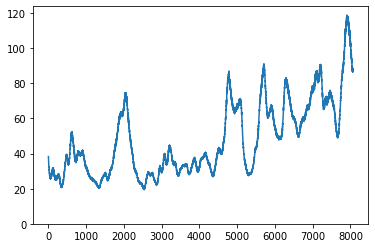

In [271]:
# Variance prod wind
env.set_id(0)
var = zeros(8063)
for i in range(48):
    env.reset()
    var += square(handler.data.prod_p[:, 1] - mean) / 48
plot(var)
ylim(0)

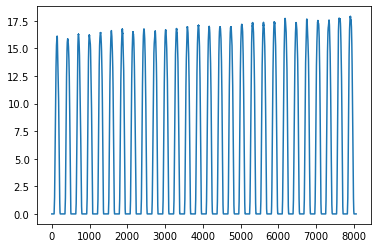

In [272]:
# Mean prod solar
env.set_id(0)
mean = zeros(8063)
for i in range(48):
    env.reset()
    mean += handler.data.prod_p[:, 6] / 48
plot(mean)

(0.0, 2.87272977768904)

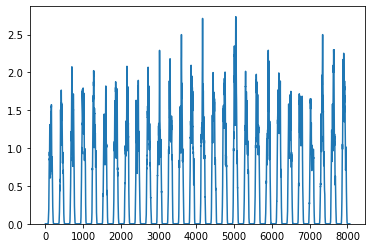

In [273]:
# Variance prod solar
env.set_id(0)
var = zeros(8063)
for i in range(48):
    env.reset()
    var += square(handler.data.prod_p[:, 6] - mean) / 48
plot(var)
ylim(0)

In [25]:
%%timeit
# random.seed(2)
env = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
# env = gp.make('rte_case14_redisp', backend=backend)
# env = gp.make('rte_case14_redisp')
env.seed(1)
obs = env.reset()
null_agent = DoNothingAgent(env.action_space)
tg_agent = TopologyGreedy(env.action_space)
rand_agent = RandomAgent(env.action_space)
# rand_agent.seed(1)
# plot_helper.plot_obs(obs)
print(env.chronics_handler.get_name())
done = False
acc_rew, duration = 0, 0
while not done:
#     ac = null_agent.act(obs, 0)
    ac = tg_agent.act(obs, 0, done)
#     ac = rand_agent.act(obs, rew, done)
    obs, rew, done, info = env.step(ac)
    acc_rew += rew
    print('step', duration)
    print(ac)
    print('reward', rew)
    duration += 2
    if duration > 0:
        break
print(acc_rew, duration)
# Takes 9.86 s ± 4.76 ms per loop (7 runs) on pandapower backend
# Takes 2.08 s ± 83.6 ms per loop (7 runs) on lightsim2grid backend
# 3min 43s ± 1.23 s per loop for 1 step for topo-greedy agent on lightsim2grid backend

Scenario_april_001
step 0
This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - Set the bus of the following element:
	 	 - assign bus 2 to line (extremity) 36 [on substation 26]
	 	 - assign bus 1 to line (extremity) 37 [on substation 26]
	 	 - assign bus 1 to line (extremity) 38 [on substation 26]
	 	 - assign bus 2 to line (extremity) 39 [on substation 26]
	 	 - assign bus 2 to line (origin) 40 [on substation 26]
	 	 - assign bus 2 to line (origin) 41 [on substation 26]
	 	 - assign bus 1 to line (extremity) 56 [on substation 26]
	 	 - assign bus 1 to generator 14 [on substation 26]
	 	 - assign bus 1 to load 27 [on substation 26]
reward 945.6219
945.6218872070312 2
Scenario_april_001
step 0
This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switc

In [179]:
# PandaPower backend
# Scenario_april_001
# 323931.7568359375 338

# LightSim2Grid backend
# Scenario_april_001
# 323931.7568359375 338

(220844.39575195312, 182)

In [166]:
env.backend._grid

This pandapower network includes the following parameter tables:
   - bus (72 elements)
   - load (37 elements)
   - gen (22 elements)
   - shunt (6 elements)
   - line (55 elements)
   - trafo (4 elements)
   - bus_geodata (36 elements)
 and the following results tables:
   - res_bus (72 elements)
   - res_line (55 elements)
   - res_trafo (4 elements)
   - res_load (37 elements)
   - res_shunt (6 elements)
   - res_gen (22 elements)

(array([54.,  1.,  1.,  0.,  0.,  2.,  0.,  0.,  0.,  1.]),
 array([3.6090851e-02, 5.5074425e+01, 1.1011276e+02, 1.6515109e+02,
        2.2018942e+02, 2.7522775e+02, 3.3026608e+02, 3.8530444e+02,
        4.4034277e+02, 4.9538110e+02, 5.5041943e+02], dtype=float32),
 <BarContainer object of 10 artists>)

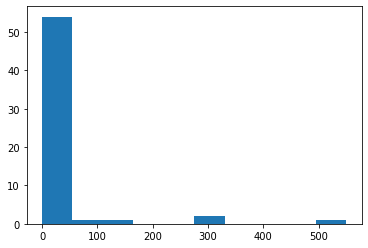

In [43]:
hist(abs(obs.a_ex - obs.a_or))

In [54]:
gen_p, *_ = env.backend.generators_info()
load_p, *_ = env.backend.loads_info()
losses = np.sum(gen_p) - np.sum(load_p)

In [55]:
losses

8.949646

In [46]:
env.backend.thermal_limit_a

array([ 60.9, 231.9, 272.6, 212.8, 749.2, 332.4, 348. , 414.4, 310.1,
       371.4, 401.2, 124.3, 298.5,  86.4, 213.9, 160.8, 112.2, 291.4,
       489. , 489. , 124.6, 196.7, 191.9, 238.4, 174.2, 105.6, 143.7,
       293.4, 288.9, 107.7, 415.5, 148.2, 124.2, 154.4,  85.9, 106.5,
       142. , 124. , 130.2,  86.2, 278.1, 182. , 592.1, 173.1, 249.8,
       441. , 344.2, 722.8, 494.6, 494.6, 196.7, 151.8, 263.4, 364.1,
       327. , 370.5, 441. , 300.3, 656.2], dtype=float32)

In [52]:
obs.a_or / env.backend.thermal_limit_a

array([0.48998854, 0.42465356, 0.18503264, 0.21732023, 0.55629253,
       0.15559176, 0.16053359, 0.20572583, 0.14581293, 0.1666989 ,
       0.19726606, 0.54849666, 0.32839015, 0.45561936, 0.23353058,
       0.27478808, 0.19711332, 0.12477103, 0.33605427, 0.33605427,
       0.43736455, 0.30599862, 0.63086545, 0.62163264, 0.34693137,
       0.35580322, 0.22974794, 0.3577181 , 0.3589641 , 0.10685792,
       0.08582752, 0.14597568, 0.57681316, 0.61922306, 0.52963084,
       0.6054083 , 0.49540216, 0.21075396, 0.20838507, 0.90143657,
       0.25471228, 0.45693868, 0.27873683, 0.2123924 , 0.01801461,
       0.51210463, 0.4175618 , 0.43482938, 0.27092895, 0.27092895,
       0.29016185, 0.25283307, 0.31343007, 0.18966922, 0.16169983,
       0.6307904 , 0.51210463, 0.33855483, 0.6271388 ], dtype=float32)

In [50]:
obs.rho

array([0.48998854, 0.42465356, 0.18503264, 0.21732023, 0.55629253,
       0.15559176, 0.16053359, 0.20572583, 0.14581293, 0.1666989 ,
       0.19726606, 0.54849666, 0.32839015, 0.45561936, 0.23353058,
       0.27478808, 0.19711332, 0.12477103, 0.33605427, 0.33605427,
       0.43736455, 0.30599862, 0.63086545, 0.62163264, 0.34693137,
       0.35580322, 0.22974794, 0.3577181 , 0.3589641 , 0.10685792,
       0.08582752, 0.14597568, 0.57681316, 0.61922306, 0.52963084,
       0.6054083 , 0.49540216, 0.21075396, 0.20838507, 0.90143657,
       0.25471228, 0.45693868, 0.27873683, 0.2123924 , 0.01801461,
       0.51210463, 0.4175618 , 0.43482938, 0.27092895, 0.27092895,
       0.29016185, 0.25283307, 0.31343007, 0.18966922, 0.16169983,
       0.6307904 , 0.51210463, 0.33855483, 0.6271388 ], dtype=float32)

In [228]:
sum(2**env.sub_info)

133908

In [229]:
len(conv.all_actions) - _

255

In [231]:
len(env.gen_type)

22

In [225]:
env.dim_topo

177

(array([17.,  3.,  8.,  4.,  2.,  1.,  0.,  0.,  0.,  1.]),
 array([ 2. ,  3.5,  5. ,  6.5,  8. ,  9.5, 11. , 12.5, 14. , 15.5, 17. ]),
 <BarContainer object of 10 artists>)

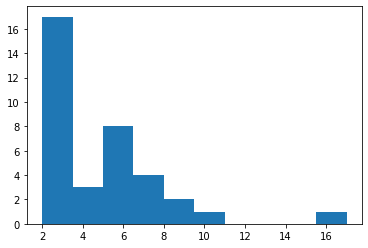

In [232]:
hist(env.sub_info)

(array([12., 13.,  6., 10.,  6.,  4.,  4.,  1.,  1.,  2.]),
 array([ 60.9    , 129.73   , 198.56   , 267.39   , 336.22   , 405.05002,
        473.88   , 542.71   , 611.54004, 680.37   , 749.2    ],
       dtype=float32),
 <BarContainer object of 10 artists>)

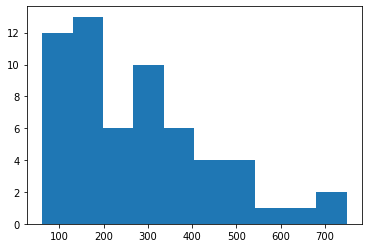

In [163]:
hist(env._thermal_limit_a)

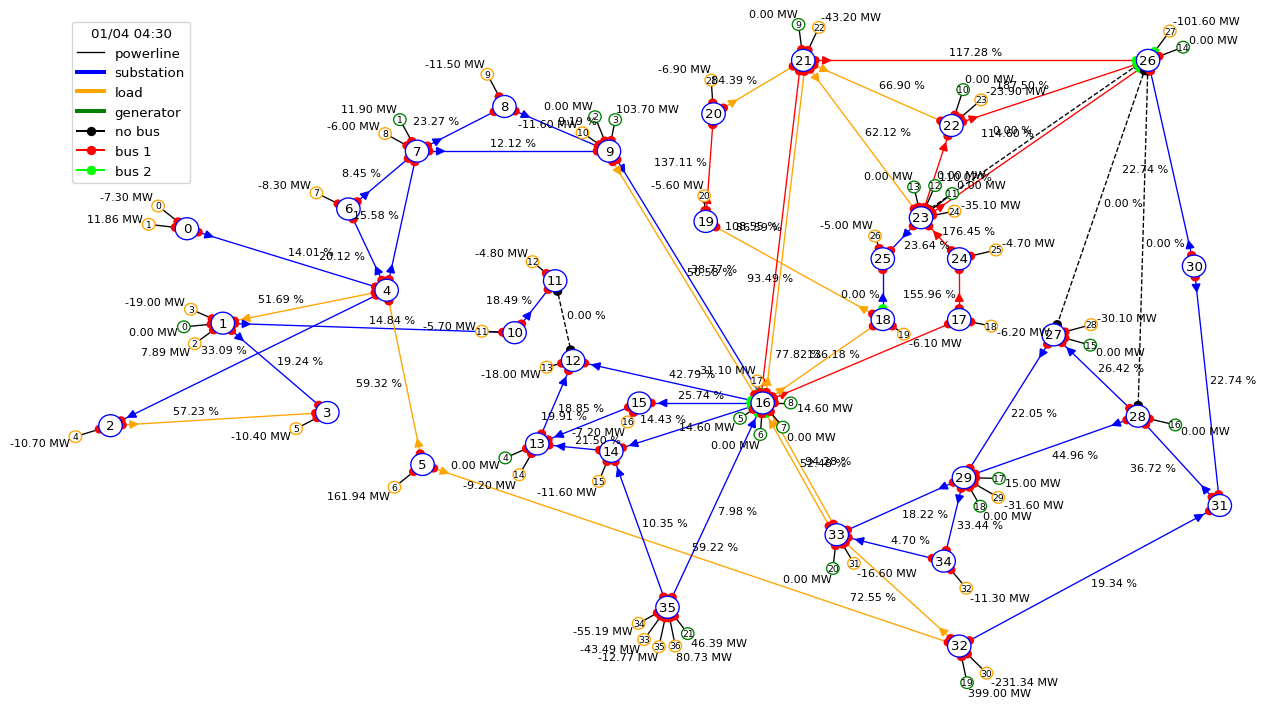

In [144]:
fig = plot_helper.plot_obs(obs)

In [22]:
info

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False,  True, False,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True,  True, False,  True, False, False, False, False, False,
        False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': False,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, 

In [24]:
# Null agent total reward
acc_rew

331917.9280395508

In [29]:
acc_rew

320567.1735839844

In [31]:
env.chronics_handler.get_name()

'Scenario_april_003'

In [52]:
obs.prod_p.sum() - obs.load_p.sum()

14.229858

In [53]:
obs.prod_q.sum() - obs.load_q.sum()

-285.92548

In [66]:
sim_obs, sim_rew, sim_done, sim_info = obs.simulate(env.action_space({}))

In [69]:
sim_info

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': False,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': None,
 'opponent_attack_sub': None,
 'opponent_attack_duration': 0,
 'exception': [],
 'rewards': {}}

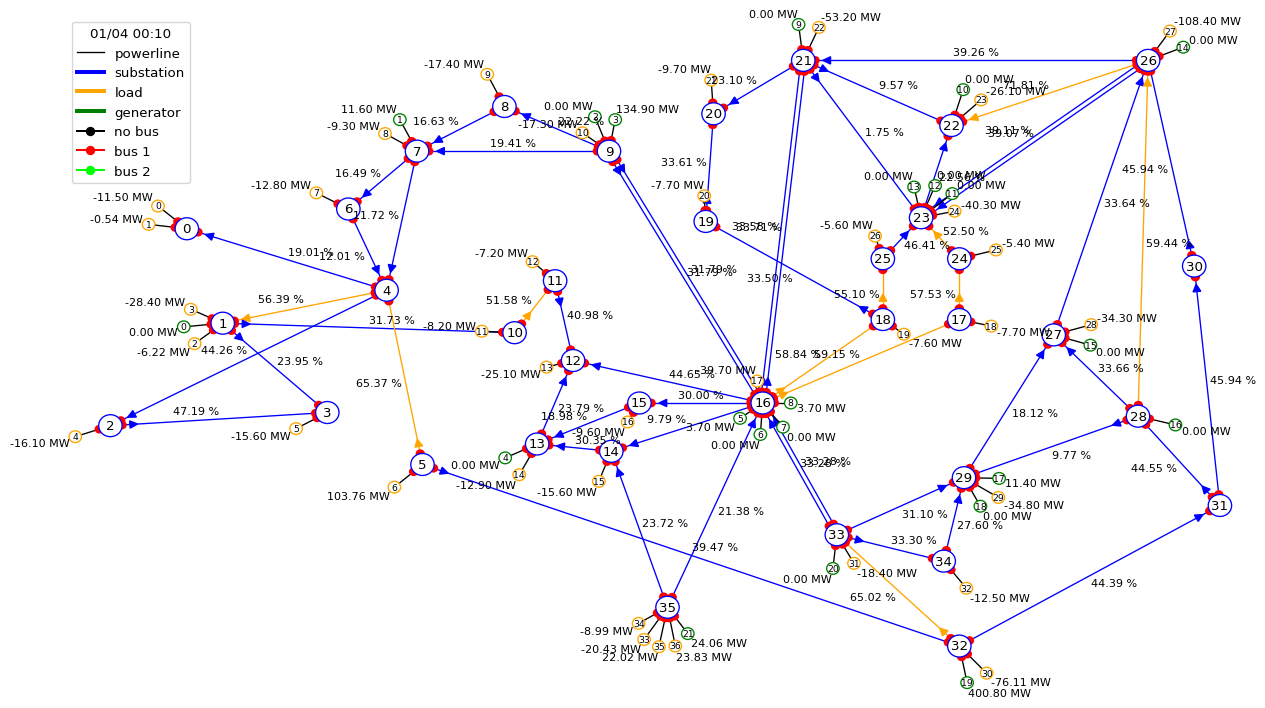

In [74]:
fig = plot_helper.plot_obs(sim_obs)

In [76]:
sim_obs.simulate(env.action_space({}))

NoForecastAvailable: Grid2OpException NoForecastAvailable "No forecasts are available for this instance of BaseObservation (no action_space and no simulated environment are set)."

In [83]:
from grid2op.Converter import IdToAct

In [100]:
conv = IdToAct(env.action_space)

In [104]:
conv.convert_act(1)

IndexError: list index out of range

In [95]:
_92.as_dict()

{}

In [96]:
env.reset()

In [103]:
conv.sample()

0

In [105]:
env.action_space.n

494

In [106]:
env.action_space.sample()

In [109]:
conv.init_converter()

In [111]:
len(conv.all_actions)

134163

In [112]:
conv.all_actions[100]

In [116]:
conv.all_actions[1500].to_vect()

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 2., 2., 2., 2., 2., 2., 2., 1., 1., 1., 1., 2.,
       1., 2., 1., 1., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [117]:
sqrt(134000)

366.0601043544625

In [283]:
# Compare OPF baseline with the null agent
from l2rpn_baselines import PandapowerOPFAgent

AttributeError: module 'l2rpn_baselines' has no attribute 'PandapowerOPFAgent'

In [239]:
l2rpn_baselines.DoNothing

<module 'l2rpn_baselines.DoNothing' from '/home/dai/.pyenv/versions/3.6.8/envs/l2rpn/lib/python3.6/site-packages/l2rpn_baselines/DoNothing/__init__.py'>

In [281]:
dir(l2rpn_baselines)

['DeepQSimple',
 'DoNothing',
 'DoubleDuelingDQN',
 'DoubleDuelingRDQN',
 'DuelQLeapNet',
 'DuelQSimple',
 'LeapNetEncoded',
 'SACOld',
 'SliceRDQN',
 'Template',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 'utils']

In [242]:
l2rpn_baselines.__all__

['Template',
 'DoubleDuelingDQN',
 'DoubleDuelingRDQN',
 'DoNothing',
 'SliceRDQN',
 'DeepQSimple',
 'DuelQSimple',
 'LeapNetEncoded',
 'SACOld',
 'PandapowerOPFAgent',
 'Geirina',
 'AsynchronousActorCritic',
 'utils']

In [282]:
import importlib
importlib.reload(l2rpn_baselines)

<module 'l2rpn_baselines' from '/home/dai/.pyenv/versions/3.6.8/envs/l2rpn/lib/python3.6/site-packages/l2rpn_baselines/__init__.py'>

In [7]:
f = lambda : (1, 2, 3)

In [11]:
x, *_ = f()

In [13]:
_

[2, 3]

In [16]:
env_pp = gp.make('l2rpn_neurips_2020_track1_small')
env_pp.reset()
env_ls = gp.make('l2rpn_neurips_2020_track1_small', backend=backend)
env_ls.reset()

In [17]:
env_pp.backend

In [65]:
env_ls.backend.n_sub

36

In [66]:
print(env_ls.backend._grid.get_Ybus())

  (0, 0)	(189.61676851904733-646.9791838483065j)
  (4, 0)	(-189.61676851904733+648.8091838483066j)
  (1, 1)	(3931.8586764568995-13836.74707168824j)
  (3, 1)	(-1096.8335259822989+3374.8723876378426j)
  (4, 1)	(-2697.1898653090816+9903.744036681783j)
  (10, 1)	(-137.8352851655192+561.0196473686144j)
  (2, 2)	(2478.4922366967594-11270.174421346977j)
  (3, 2)	(-2053.9604759319845+9352.855738618859j)
  (4, 2)	(-424.5317607647748+1918.1116827281187j)
  (1, 3)	(-1096.8335259822989+3374.8723876378426j)
  (2, 3)	(-2053.9604759319845+9352.855738618859j)
  (3, 3)	(3150.7940019142834-12727.310126256702j)
  (0, 4)	(-189.61676851904733+648.8091838483066j)
  (1, 4)	(-2697.1898653090816+9903.744036681783j)
  (2, 4)	(-424.5317607647748+1918.1116827281187j)
  (4, 4)	(3759.8562663481675-16524.341482002987j)
  (5, 4)	(-0+2852.04991087344j)
  (6, 4)	(-261.6902581929024+864.1485161510172j)
  (7, 4)	(-186.82761356236153+529.2923959270951j)
  (4, 5)	(-0+2852.04991087344j)
  (5, 5)	(91.90932607399952-4003.8209

In [70]:
env_ls.backend._grid.get_Ybus()

<37x37 sparse matrix of type '<class 'numpy.complex128'>'
	with 147 stored elements in Compressed Sparse Column format>

In [76]:
obs.connectivity_matrix().shape

(177, 177)

In [78]:
obs.bus_connectivity_matrix().shape

(37, 37)

In [81]:
obs.dim_topo

177

In [82]:
obs.n_gen + 2 * obs.n_line + obs.n_load

177

In [80]:
obs.n_gen, obs.n_line, obs.n_load, obs.n_sub

(22, 59, 37, 36)

In [87]:
change_bus = env.action_space({
    'change_bus': {
        'lines_or_id': [10]
    }
})
print(change_bus)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - Change the bus of the following element:
	 	 - switch bus of line (origin) 0 [on substation 2]
	 - NOT force any particular bus configuration


In [88]:
env.step(change_bus)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7f7b678b2e10>,
 946.5845,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [],
  'rewards': {}})

In [91]:
obs_after = _88[0]

In [111]:
env.backend.name_line

array(['34_35_110', '34_36_111', '32_36_112', '33_35_113', '33_36_114',
       '36_38_115', '36_39_116', '38_39_119', '39_40_120', '39_41_121',
       '40_41_122', '42_43_123', '33_42_124', '43_44_125', '44_45_126',
       '45_46_127', '45_47_128', '46_48_130', '41_48_131', '41_48_132',
       '44_48_133', '47_48_134', '48_49_135', '48_50_136', '50_51_137',
       '51_52_138', '52_53_139', '48_53_141', '48_53_142', '53_54_143',
       '53_55_144', '54_55_145', '55_56_146', '49_56_147', '55_57_148',
       '50_57_149', '53_58_150', '55_58_152', '55_58_153', '54_58_154',
       '58_59_155', '58_60_156', '59_60_157', '59_61_158', '60_61_159',
       '62_63_160', '37_64_161', '63_64_163', '48_65_164', '48_65_165',
       '61_65_166', '61_66_167', '65_66_168', '46_68_169', '48_68_170',
       '37_36_179', '62_58_180', '63_60_181', '64_65_182'], dtype='<U9')

In [102]:
env.backend._grid.nb_bus()

38

In [107]:
env.backend._grid.get_Ybus()

<38x38 sparse matrix of type '<class 'numpy.complex128'>'
	with 148 stored elements in Compressed Sparse Column format>

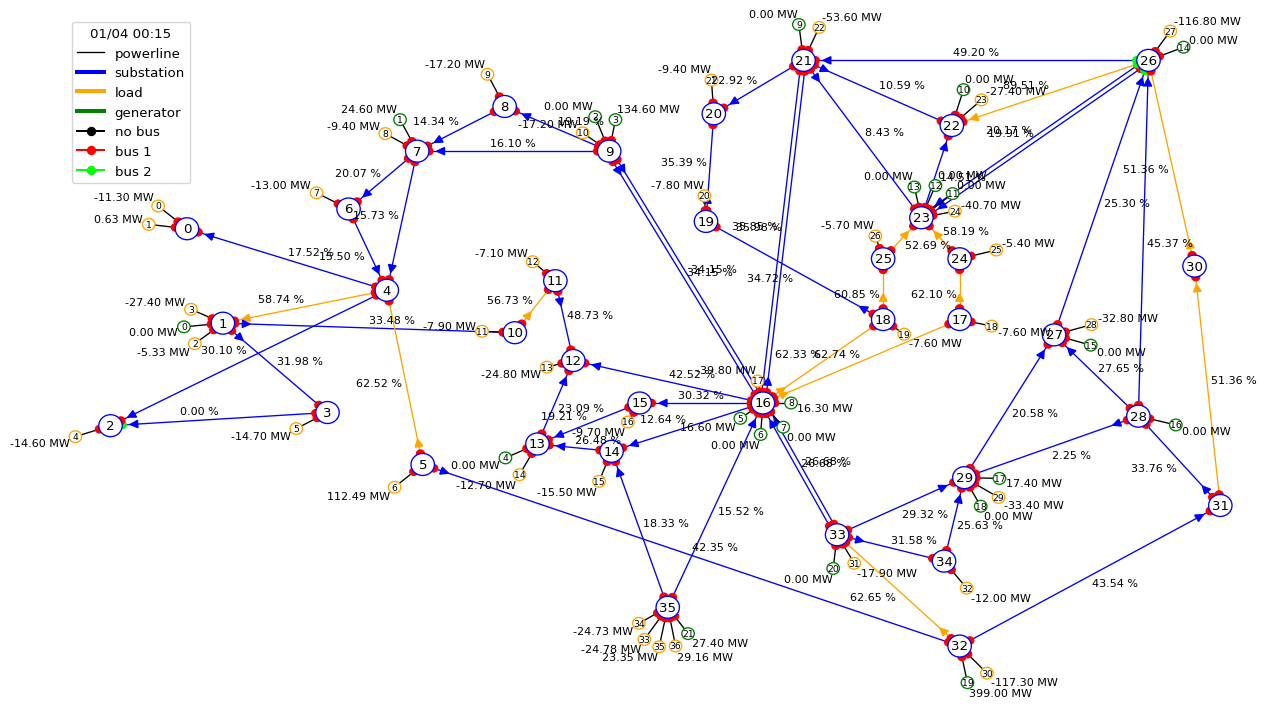

In [246]:
fig = plot_helper.plot_obs(obs_after)

In [144]:
env.action_space.get_obj_connect_to(substation_id=11)

{'loads_id': array([12]),
 'generators_id': array([], dtype=int64),
 'lines_or_id': array([13]),
 'lines_ex_id': array([11]),
 'nb_elements': 3}

In [244]:
env.set_id(0)
obs = env.reset()
# plot_helper.plot_obs(obs)
done = False
while not done:
    ac = env.action_space({
#         'set_line_status': [
#             (13, -1),
#         ],
        'set_bus': {
            'generators_id': [
              (0, 2),
            ],
            'lines_or_id': [
              (3, 2),
            ],
        },
#         'change_bus': {
#             'generators_id': range(obs.n_gen)
#         }
    })
    print(ac)
    obs, rew, done, info = env.step(ac)
    print(info['exception'])

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - Set the bus of the following element:
	 	 - assign bus 2 to line (origin) 3 [on substation 1]
	 	 - assign bus 2 to generator 0 [on substation 1]
[]
This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - Set the bus of the following element:
	 	 - assign bus 2 to line (origin) 3 [on substation 1]
	 	 - assign bus 2 to generator 0 [on substation 1]
[Grid2OpException IllegalAction IllegalAction('Substation with ids [] have been modified illegally (cooldown)',)]
This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch an

In [245]:
obs.state_of(gen_id=0)

{'p': 0.0,
 'q': -23.653622,
 'v': 147.8,
 'bus': 2,
 'sub_id': 1,
 'target_dispatch': 0.0,
 'actual_dispatch': 0.0}

In [218]:
info

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True,  True, False, False, False,
        False, False, False, False,  True,  True,  True,  True,  True,
        False, False, False,  True, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': False,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': None,
 'opponent_attack_sub': None,
 'opponent_attack_duration': 0,
 'exception': [Grid2OpException DivergingPowerFlow DivergingPowerFlow('GAME OVER: Powerflow has diverged during computation or a load has been disconnected or a generator has been disconnected.',)],
 'rewards': {}}

In [194]:
obs.line_status

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

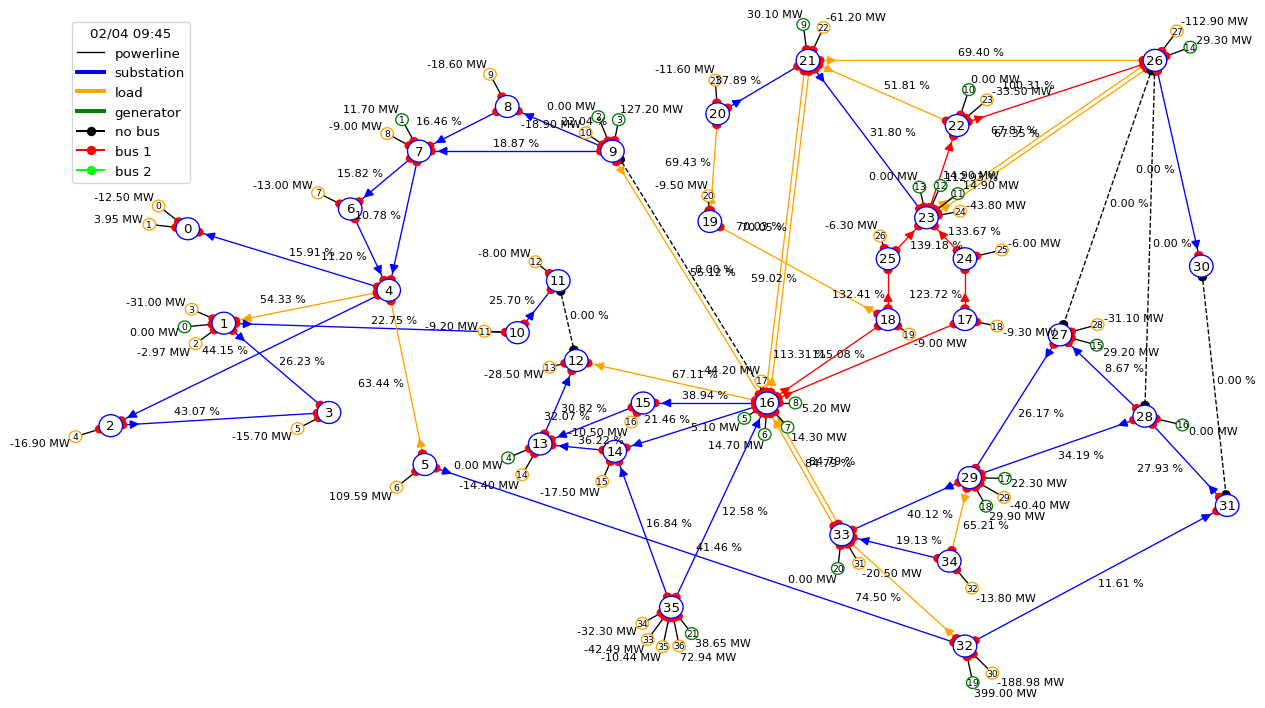

In [217]:
_ = plot_helper.plot_obs(obs)

In [173]:
obs.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1, 6443,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1, 2987,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 4715,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1, 5291,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [174]:
obs.duration_next_maintenance

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0, 96,  0,  0,  0,  0,  0,  0,  0,
        0, 96,  0,  0,  0,  0,  0,  0,  0,  0, 96,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, 96,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0], dtype=int32)

In [193]:
obs.time_before_cooldown_line

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [204]:
ac = env.action_space({
    'change_line_status': [0, 1],
#     'change_bus': {
#       'lines_ex_id': [0],
#       'lines_or_id': [1],
#     },
})
print(ac)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - switch status of 2 powerlines ([0 1])
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration


In [205]:
obs, rew, done, info = env.step(ac)

In [206]:
info

{'disc_lines': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False]),
 'is_illegal': True,
 'is_ambiguous': False,
 'is_dispatching_illegal': False,
 'is_illegal_reco': False,
 'opponent_attack_line': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, F

In [120]:
env.action_space.grid_objects_types.shape

(177, 5)

In [207]:
env.parameters.MAX_LINE_STATUS_CHANGED, env.parameters.MAX_SUB_CHANGED

(1, 1)

In [157]:
env_pp.backend._grid.line

,c_nf_per_km,df,from_bus,g_us_per_km,in_service,length_km,max_i_ka,max_loading_percent,name,parallel,r_ohm_per_km,std_type,to_bus,type,x_ohm_per_km,old_from_bus,old_to_bus,old_name
0,37.328927,1.0,2,0.0,True,1.0,99999,100.0,34_35_110,1,0.426586,None,3,ol,1.942488,34,35,34_35_110
1,183.580318,1.0,2,0.0,True,1.0,99999,100.0,34_36_111,1,2.094840,None,4,ol,9.464868,34,36,34_36_111
2,509.790565,1.0,0,0.0,True,1.0,99999,100.0,32_36_112,1,7.903260,None,4,ol,27.042480,32,36,32_36_112
3,79.115039,1.0,1,0.0,True,1.0,99999,100.0,33_35_113,1,1.658732,None,3,ol,5.103792,33,35,33_35_113
4,137.058447,1.0,1,0.0,True,1.0,99999,100.0,33_36_114,1,0.487526,None,4,ol,1.790136,33,36,33_36_114
5,376.075007,1.0,4,0.0,True,1.0,99999,100.0,36_38_115,1,6.113124,None,6,ol,20.186640,36,38,36_38_115
6,585.005567,1.0,4,0.0,True,1.0,99999,100.0,36_39_116,1,11.293092,None,7,ol,31.993920,36,39,36_39_116
7,216.173486,1.0,6,0.0,True,1.0,99999,100.0,38_39_119,1,3.504096,None,7,ol,11.521620,38,39,38_39_119
8,170.208763,1.0,7,0.0,True,1.0,99999,100.0,39_40_120,1,2.761380,None,8,ol,9.274428,39,40,39_40_120
9,649.077605,1.0,7,0.0,True,1.0,99999,100.0,39_41_121,1,10.569420,None,9,ol,34.850520,39,41,39_41_121


In [61]:
env_pp.backend._grid.trafo

,df,hv_bus,i0_percent,in_service,lv_bus,max_loading_percent,name,parallel,pfe_kw,shift_degree,...,tap_side,tap_step_degree,tap_step_percent,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,old_hv_bus,old_lv_bus,old_name
0,1.0,5,0.0,True,4,100.0,37_36_179,1,0.0,0.0,...,hv,NaN,6.5,345.0,138.0,371.25,0.0,37,36,37_36_179
1,1.0,30,0.0,True,26,100.0,62_58_180,1,0.0,0.0,...,hv,NaN,4.0,345.0,138.0,382.14,0.0,62,58,62_58_180
2,1.0,31,0.0,True,28,100.0,63_60_181,1,0.0,0.0,...,hv,NaN,1.5,345.0,138.0,265.32,0.0,63,60,63_60_181
3,1.0,32,0.0,True,33,100.0,64_65_182,1,0.0,0.0,...,hv,NaN,6.5,345.0,138.0,366.30,0.0,64,65,64_65_182


In [69]:
env_pp.backend._grid.gen

,bus,controllable,in_service,name,p_mw,scaling,sn_mva,type,vm_pu,slack,...,max_ramp_down,min_up_time,min_down_time,marginal_cost,start_cost,category,shut_down_cost,zone,old_bus,old_name
0,1,True,True,gen_33_16,0.000000,1.0,NaN,thermal,1.071015,False,...,1.418440,72.0,96.0,45.0,79.51,biomass,0,R2,33,gen_33_16
1,7,True,True,gen_39_17,25.299999,1.0,NaN,wind,1.071015,False,...,NaN,0.0,0.0,0.0,0.00,wind,0,R2,39,gen_39_17
2,9,True,True,gen_41_18,0.000000,1.0,NaN,thermal,1.071015,False,...,1.418440,60.0,96.0,46.0,39.75,biomass,0,R2,41,gen_41_18
3,9,True,True,gen_41_19,134.399994,1.0,NaN,hydro,1.071015,False,...,10.416667,12.0,12.0,36.0,0.00,hydro,0,R2,41,gen_41_19
4,13,True,True,gen_45_20,0.000000,1.0,NaN,thermal,1.071015,False,...,1.418440,60.0,36.0,48.0,114.97,naturalgas,0,R2,45,gen_45_20
5,16,True,True,gen_48_21,16.600000,1.0,NaN,wind,1.071015,False,...,NaN,0.0,0.0,0.0,0.00,wind,0,R2,48,gen_48_21
6,16,True,True,gen_48_22,0.000000,1.0,NaN,solar,1.071015,False,...,NaN,0.0,0.0,0.0,0.00,solar,0,R2,48,gen_48_22
7,16,True,True,gen_48_23,0.000000,1.0,NaN,solar,1.071015,False,...,NaN,0.0,0.0,0.0,0.00,solar,0,R2,48,gen_48_23
8,16,True,True,gen_48_24,16.600000,1.0,NaN,wind,1.071015,False,...,NaN,0.0,0.0,0.0,0.00,wind,0,R2,48,gen_48_24
9,21,True,True,gen_53_25,0.000000,1.0,NaN,solar,1.071015,False,...,NaN,0.0,0.0,0.0,0.00,solar,0,R2,53,gen_53_25


In [196]:
env_pp.backend._grid.load

,bus,const_i_percent,const_z_percent,controllable,in_service,name,p_mw,q_mvar,scaling,sn_mva,type,PF,zone,old_bus,old_name
0,0,0.0,0.0,False,True,load_32_26,12.000000,8.200000,1.0,NaN,None,0.013266,R2,32,load_32_26
1,0,0.0,0.0,False,True,interco_14_32,-1.140000,-2.190000,1.0,NaN,None,NaN,None,32,interco_14_32
2,1,0.0,0.0,False,True,interco_18_33,5.120000,-5.150000,1.0,NaN,None,NaN,None,33,interco_18_33
3,1,0.0,0.0,False,True,load_33_27,28.500000,19.700001,1.0,NaN,None,0.034024,R2,33,load_33_27
4,2,0.0,0.0,False,True,load_34_28,15.300000,10.600000,1.0,NaN,None,0.019030,R2,34,load_34_28
5,3,0.0,0.0,False,True,load_35_29,14.800000,10.500000,1.0,NaN,None,0.017878,R2,35,load_35_29
6,5,0.0,0.0,False,True,interco_29_37,-112.860001,-36.730000,1.0,NaN,None,NaN,None,37,interco_29_37
7,6,0.0,0.0,False,True,load_38_30,13.100000,9.400000,1.0,NaN,None,0.014668,R2,38,load_38_30
8,7,0.0,0.0,False,True,load_39_31,9.500000,6.800000,1.0,NaN,None,0.010749,R2,39,load_39_31
9,8,0.0,0.0,False,True,load_40_32,17.700001,12.100000,1.0,NaN,None,0.020100,R2,40,load_40_32


In [124]:
env.reset()

In [126]:
env.backend._grid.nb_bus()

36

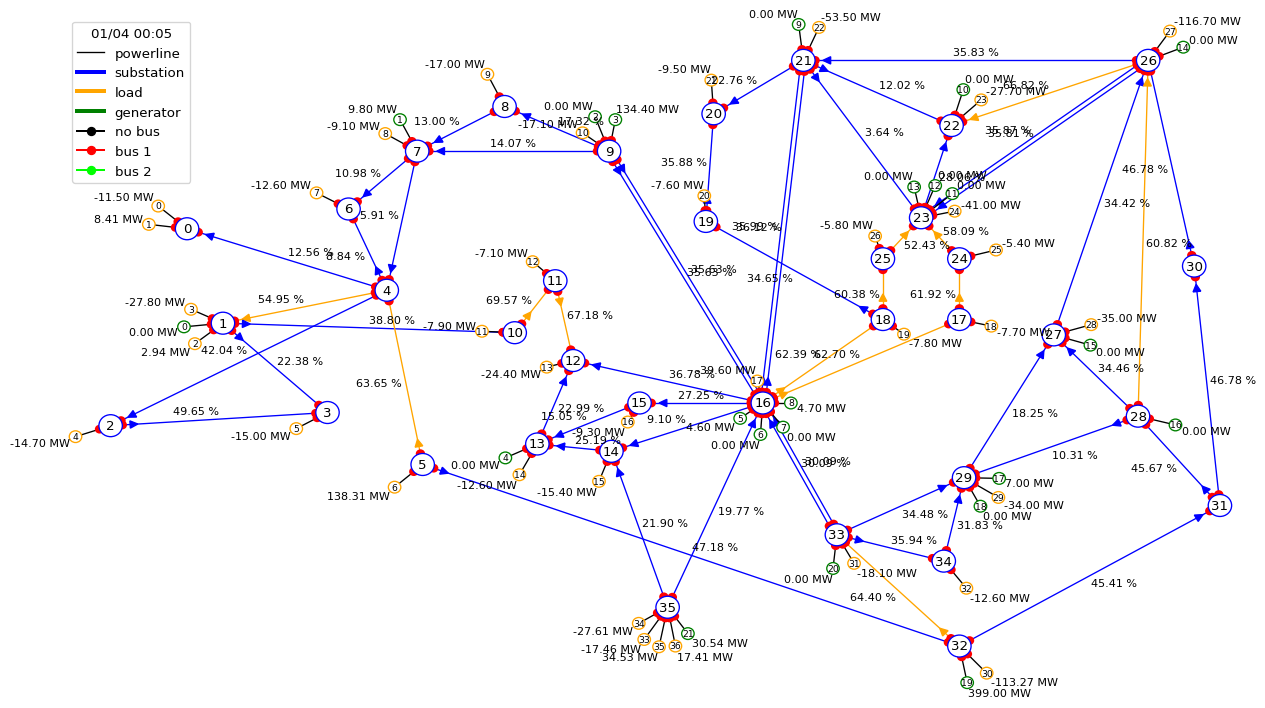

In [129]:
_ = plot_helper.plot_obs(_124)

In [251]:
env.set_id(0); env.reset()

NameError: name 'args' is not defined

In [255]:
runner = gp.Runner.Runner(**env.get_params_for_runner(), agentClass=DoNothingAgent)

In [256]:
runner.run(nb_episode=10)

[('/root/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_000',
  'Scenario_april_000',
  465577.28125,
  497,
  8062),
 ('/root/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_001',
  'Scenario_april_001',
  81484.8125,
  79,
  8062),
 ('/root/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_002',
  'Scenario_april_002',
  459036.65625,
  486,
  8062),
 ('/root/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_003',
  'Scenario_april_003',
  436575.25,
  478,
  8062),
 ('/root/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_004',
  'Scenario_april_004',
  511736.625,
  535,
  8062),
 ('/root/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_005',
  'Scenario_april_005',
  695889.75,
  748,
  8062),
 ('/root/data_grid2op/l2rpn_neurips_2020_track1_small/chronics/Scenario_april_006',
  'Scenario_april_006',
  179906.328125,
  186,
  8062),
 ('/root/data_grid2op/l2rpn_ne

In [306]:
env.reset()

In [307]:
%%timeit
env.backend.runpf()

# env.backend.initdc = False
# 124 µs ± 110 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)
# env.backend.initdc = True
# 323 µs ± 906 ns per loop (mean ± std. dev. of 7 runs, 1000 loops each)

125 µs ± 46.1 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [305]:
env.backend.initdc = False

In [293]:
env.backend.a_or

array([ 32.188663,  93.48466 ,  34.08444 ,  43.0572  , 410.93304 ,
        30.076092,  13.260732,  34.173817,  41.51264 ,  53.20779 ,
        70.62124 ,  88.20203 , 117.17816 ,  60.174328,  47.722004,
        40.1919  ,  15.480383,  24.278177, 172.80577 , 172.80577 ,
        43.547607,  52.147   , 121.58144 , 149.24814 ,  60.645172,
        38.05893 ,  32.89956 , 106.21071 , 104.93802 ,  12.611001,
        13.465468,  40.990017,  72.042305,  96.19397 ,  45.443077,
        64.77554 ,  52.938496,  46.231853,  48.479374,  59.687912,
        97.70945 , 112.78287 , 205.92885 ,  32.50093 ,  25.05263 ,
       208.77806 , 163.23924 , 332.17203 , 155.2454  , 155.2454  ,
        67.545425,  48.200912,  94.17516 ,  82.50041 ,  67.94864 ,
       236.47014 , 208.77806 , 138.41632 , 425.32828 ], dtype=float32)

In [281]:
env_pp.backend.runpf(False)

True

In [283]:
env_pp.backend.a_or

array([ 29.281418 ,  99.16286  ,  48.522953 ,  46.797718 , 416.7919   ,
        50.572147 ,  54.16704  ,  83.15019  ,  43.81485  ,  59.623062 ,
        77.338196 ,  70.34054  , 100.91266  ,  41.296402 ,  50.73131  ,
        44.11436  ,  21.97206  ,  35.72619  , 166.33752  , 166.33752  ,
        54.273922 ,  59.674496 , 122.203415 , 150.86784  ,  61.60955  ,
        38.22674  ,  32.8176   , 107.53291  , 106.23608  ,  12.858382 ,
        14.377919 ,  41.622807 ,  73.67701  ,  97.47416  ,  46.334805 ,
        65.4049   ,  50.23033  ,  43.869274 ,  45.983818 ,  56.86421  ,
        98.99822  , 112.610344 , 190.02159  ,  42.942936 ,   4.2211323,
       202.8654   , 145.31549  , 311.3488   , 135.66055  , 135.66055  ,
        60.673107 ,  41.861694 ,  86.25437  ,  69.38862  ,  53.300766 ,
       233.98872  , 202.8654   , 123.84628  , 413.86084  ], dtype=float32)

In [277]:
env_pp.backend.runpf()
x_ac = env_pp.backend.a_or.copy()
env_pp.backend.runpf(False)
x_dc = env_pp.backend.a_or.copy()

In [278]:
x_ac - x_dc

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)

In [280]:
x_dc

array([ 29.281418 ,  99.16286  ,  48.522953 ,  46.797718 , 416.7919   ,
        50.572147 ,  54.16704  ,  83.15019  ,  43.81485  ,  59.623062 ,
        77.338196 ,  70.34054  , 100.91266  ,  41.296402 ,  50.73131  ,
        44.11436  ,  21.97206  ,  35.72619  , 166.33752  , 166.33752  ,
        54.273922 ,  59.674496 , 122.203415 , 150.86784  ,  61.60955  ,
        38.22674  ,  32.8176   , 107.53291  , 106.23608  ,  12.858382 ,
        14.377919 ,  41.622807 ,  73.67701  ,  97.47416  ,  46.334805 ,
        65.4049   ,  50.23033  ,  43.869274 ,  45.983818 ,  56.86421  ,
        98.99822  , 112.610344 , 190.02159  ,  42.942936 ,   4.2211323,
       202.8654   , 145.31549  , 311.3488   , 135.66055  , 135.66055  ,
        60.673107 ,  41.861694 ,  86.25437  ,  69.38862  ,  53.300766 ,
       233.98872  , 202.8654   , 123.84628  , 413.86084  ], dtype=float32)

In [308]:
env_clone = env.copy()

In [309]:
env_clone.backend.a_or

array([ 31.247551,  93.64753 ,  47.72459 ,  41.593006, 413.6392  ,
        40.857918,  42.3539  ,  68.38238 ,  45.699543,  63.98819 ,
        80.34235 ,  69.72936 ,  98.52761 ,  42.450237,  44.980797,
        41.34503 ,  17.817612,  25.048391, 164.2781  , 164.2781  ,
        46.840405,  52.839783, 119.987045, 147.19284 ,  59.10604 ,
        37.649357,  31.872717, 104.77818 , 103.53163 ,  12.48741 ,
        15.220085,  39.280033,  70.94044 ,  94.909096,  44.489185,
        64.11987 ,  50.6     ,  44.226753,  46.361557,  57.134686,
        95.79666 , 110.183685, 197.53049 ,  39.37227 ,  11.859476,
       202.59483 , 143.82585 , 316.08875 , 142.50774 , 142.50774 ,
        62.41945 ,  43.296505,  88.76013 ,  76.88775 ,  62.195934,
       233.04109 , 202.59483 , 128.95854 , 417.5857  ], dtype=float32)

In [348]:
handler = env.chronics_handler
obs = env.get_obs()

In [323]:
handler.data.forecasts()

[(datetime.datetime(2012, 4, 1, 0, 10),
  {'injection': {'load_p': array([  10.6 ,    0.15,    5.03,   25.4 ,   14.  ,   13.6 , -110.53,
             11.9 ,    8.7 ,   16.3 ,   16.4 ,    7.5 ,    6.7 ,   22.9 ,
             11.7 ,   14.2 ,    8.8 ,   37.4 ,    7.7 ,    7.7 ,    7.3 ,
              9.2 ,   53.3 ,   27.  ,   40.9 ,    5.5 ,    5.7 ,  113.5 ,
             35.5 ,   35.7 ,  105.09,   18.4 ,   12.6 ,   18.25,   23.39,
            -28.99,  -20.02], dtype=float32),
    'load_q': array([   7.4 ,   -1.92,   -5.13,   17.8 ,    9.8 ,    9.5 ,  -36.93,
              8.3 ,    6.1 ,   11.4 ,   11.5 ,    5.2 ,    4.7 ,   16.  ,
              8.2 ,   10.  ,    6.2 ,   26.2 ,    5.4 ,    5.4 ,    5.1 ,
              6.5 ,   37.3 ,   18.9 ,   28.6 ,    3.8 ,    4.  ,   79.5 ,
             24.9 ,   25.  ,    0.79,   12.9 ,    8.8 ,    0.29,  -12.82,
              0.38, -195.23], dtype=float32),
    'prod_p': array([  0. ,  14.4,   0. , 135.5,   0. ,   7.7,   0. ,   0. ,   7.6,
           

In [327]:
handler.data.maintenance.shape

(8063, 59)

In [340]:
handler.data.line_to_maintenance

{'34_35_110',
 '39_41_121',
 '41_48_131',
 '43_44_125',
 '44_45_126',
 '48_50_136',
 '48_53_141',
 '54_58_154',
 '62_58_180',
 '62_63_160'}

In [341]:
len(handler.data.line_to_maintenance)

10

In [344]:
# Per month
handler.data.daily_proba_per_month_maintenance

[0.0, 0.0, 0.0, 0.02, 0.02, 0.03, 0.05, 0.06, 0.03, 0.02, 0.0, 0.0]

In [345]:
handler.data.max_daily_number_per_month_maintenance

[0, 0, 0, 1, 1, 2, 2, 2, 1, 1, 0, 0]

In [349]:
handler.data.maintenance.sum(axis=0)

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 96,  0,  0,  0,
        0, 96,  0,  0,  0,  0,  0,  0,  0,  0, 96,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0, 96,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0])

In [350]:
obs.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1, 6732,   -1,   -1,   -1,   -1, 5004,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 5292,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1, 7308,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [330]:
# How accurate are the provided forecasts?
handler.data.prod_p_forecast.shape

(8063, 22)

(array([1.00000e+00, 0.00000e+00, 0.00000e+00, 4.00000e+00, 0.00000e+00,
        9.00000e+00, 1.60000e+01, 2.90000e+01, 4.10000e+01, 6.40000e+01,
        1.02000e+02, 1.62000e+02, 1.73000e+02, 2.56000e+02, 3.40000e+02,
        4.77000e+02, 7.22000e+02, 1.16500e+03, 1.92800e+03, 2.44570e+04,
        1.41824e+05, 1.86800e+03, 1.15800e+03, 7.83000e+02, 4.75000e+02,
        3.87000e+02, 2.86000e+02, 2.01000e+02, 1.56000e+02, 1.20000e+02,
        8.70000e+01, 3.90000e+01, 2.10000e+01, 1.50000e+01, 9.00000e+00,
        3.00000e+00, 4.00000e+00, 3.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-16.200012 , -15.390012 , -14.580011 , -13.77001  , -12.96001  ,
        -12.150009 , -11.340009 , -10.530008 ,  -9.720007 ,  -8.9100065,
         -8.100006 ,  -7.2900057,  -6.480005 ,  -5.6700044,  -4.8600035,
         -4.050003 ,  -3.2400024,  -2.4300017,  -1.6200012,  -0.8100006,
          0.       ,   0.8100006,   1.6200012,   2.4300017,   3.2400024,
          4.050003 ,   4.8600035,   5.6700044,   

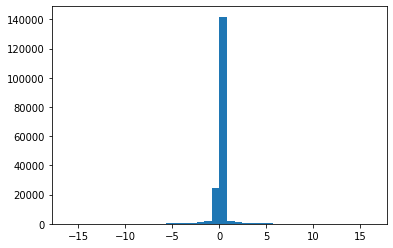

In [335]:
hist((handler.data.prod_p_forecast - handler.data.prod_p).flatten(), bins=40)

In [339]:
median(handler.data.prod_p_forecast - handler.data.prod_p)

0.0

(array([1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 2.00000e+00,
        1.00000e+00, 1.00000e+00, 2.00000e+00, 0.00000e+00, 6.00000e+00,
        6.00000e+00, 2.18000e+02, 9.01200e+03, 2.87567e+05, 1.49200e+03,
        1.90000e+01, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-137.2      , -132.3495   , -127.499    , -122.6485   ,
        -117.798    , -112.947495 , -108.097    , -103.2465   ,
         -98.395996 ,  -93.545494 ,  -88.695    ,  -83.8445   ,
         -78.993996 ,  -74.1435   ,  -69.293    ,  -64.4425   ,
         -59.592    ,  -54.741497 ,  -49.891    ,  -45.040497 ,
         -40.19     ,  -35.3395   ,  -30.488998 ,  -25.638498 ,
         -20.787998 ,  -15.937

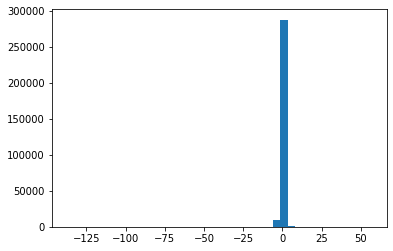

In [336]:
hist((handler.data.load_p_forecast - handler.data.load_p).flatten(), bins=40)

In [338]:
median(handler.data.load_p_forecast - handler.data.load_p)

0.0

In [352]:
print(ac)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - Set the bus of the following element:
	 	 - assign bus 2 to line (origin) 3 [on substation 1]
	 	 - assign bus 2 to generator 0 [on substation 1]


In [355]:
%%timeit
obs.simulate(ac)

2.94 ms ± 4.06 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [383]:
obs._forecasted_inj

[(datetime.datetime(2012, 4, 1, 0, 5),
  {'injection': {'load_p': array([  10.8 ,    0.13,    5.05,   25.1 ,   13.8 ,   13.7 , -109.86,
             12.  ,    8.5 ,   16.5 ,   16.5 ,    7.7 ,    6.7 ,   23.  ,
             11.9 ,   14.4 ,    8.9 ,   37.  ,    7.8 ,    7.7 ,    7.3 ,
              9.3 ,   53.3 ,   26.9 ,   41.2 ,    5.5 ,    5.8 ,  114.2 ,
             35.3 ,   35.8 ,  104.5 ,   18.1 ,   12.4 ,   17.36,   24.19,
            -31.26,  -17.4 ], dtype=float32),
    'load_q': array([   7.3 ,   -1.84,   -5.13,   17.8 ,    9.6 ,    9.5 ,  -37.01,
              8.4 ,    6.2 ,   11.6 ,   11.7 ,    5.2 ,    4.7 ,   16.  ,
              8.  ,    9.9 ,    6.2 ,   25.9 ,    5.4 ,    5.4 ,    5.2 ,
              6.5 ,   37.2 ,   19.2 ,   28.3 ,    3.8 ,    4.  ,   78.3 ,
             25.1 ,   25.2 ,    0.82,   13.  ,    8.8 ,    0.66,  -13.05,
              1.  , -195.25], dtype=float32),
    'prod_p': array([  0.      ,  14.4     ,   0.      , 134.4     ,   0.      ,
             7.

In [364]:
print(obs._forecasted_grid_act[1]['inj_action'])

This action will:
	 - set load_p to [  10.6     0.15    5.03   25.4    14.     13.6  -110.53   11.9     8.7
   16.3    16.4     7.5     6.7    22.9    11.7    14.2     8.8    37.4
    7.7     7.7     7.3     9.2    53.3    27.     40.9     5.5     5.7
  113.5    35.5    35.7   105.09   18.4    12.6    18.25   23.39  -28.99
  -20.02]
	 - set prod_p to [  0.   14.4   0.  135.5   0.    7.7   0.    0.    7.6   0.    0.    0.
   0.    0.    0.    0.    0.   16.5   0.  391.2   0.   28.9]
	 - set load_q to [   7.4    -1.92   -5.13   17.8     9.8     9.5   -36.93    8.3     6.1
   11.4    11.5     5.2     4.7    16.      8.2    10.      6.2    26.2
    5.4     5.4     5.1     6.5    37.3    18.9    28.6     3.8     4.
   79.5    24.9    25.      0.79   12.9     8.8     0.29  -12.82    0.38
 -195.23]
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - NOT force any particular bus configuration


In [373]:
obs2 = obs._obs_env.step(env.action_space({}))[0]

In [371]:
obs.time_before_cooldown_sub

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [374]:
obs._obs_env.step(env.action_space({}))

Grid2OpException: Grid2OpException "Impossible to make a step with a non initialized backend. Have you called "env.reset()" after the last game over ?"

In [378]:
obs2._obs_env

In [379]:
obs

In [381]:
obs3 = obs.simulate(ac)[0]

In [382]:
obs3._obs_env

In [385]:
obs._obs_env.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1, 6732,   -1,   -1,   -1,   -1, 5004,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 5292,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1, 7308,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [386]:
env.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1, 6732,   -1,   -1,   -1,   -1, 5004,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 5292,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1, 7308,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [387]:
obs._forecasted_grid_act[1]

{'timestamp': datetime.datetime(2012, 4, 1, 0, 10),
 'inj_action': <grid2op.Space.GridObjects.CompleteAction_l2rpn_neurips_2020_track1_small at 0x7f7b79319400>}

In [464]:
obs = env.reset()

In [459]:
obs.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 7308,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,  684,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [483]:
obs2, *_ = obs.simulate(ac)

In [436]:
obs._obs_env.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 7308,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,  684,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [470]:
obs._obs_env.simulate(ac)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7f7b8042a978>,
 -10.0,
 True,
 {'disc_lines': array([ True, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [Grid2OpException DivergingPowerFlow DivergingPowerFlow('GAME OVER: Powerflow has diverged during computation or a load has been disconnected or a generator has been disco

In [425]:
obs2.minute_of_hour

10

In [468]:
obs._obs_env.time_stamp

datetime.datetime(2012, 4, 1, 0, 10)

In [423]:
print(ac)

This action will:
	 - NOT change anything to the injections
	 - NOT perform any redispatching action
	 - NOT force any line status
	 - NOT switch any line status
	 - NOT switch anything in the topology
	 - Set the bus of the following element:
	 	 - assign bus 2 to line (origin) 3 [on substation 1]
	 	 - assign bus 2 to generator 0 [on substation 1]


In [448]:
obs._obs_env.nb_time_step

68465

In [454]:
env._backend_action.prod_p

In [452]:
obs._obs_env._backend_action.prod_p

In [456]:
obs, *_ = env.step(ac)

In [458]:
env.nb_time_step

1

In [465]:
obs.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1, 7596,   -1,
         -1,   -1, 2412,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,  972,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [461]:
null_ac = env.action_space({})

In [466]:
obs, *_ = env.step(null_ac)

In [484]:
obs.time_next_maintenance

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1, 7595,   -1,
         -1,   -1, 2411,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,  971,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [493]:
obs._obs_env._prod_p

array([  0.      ,  13.3     ,   0.      , 134.5     ,   0.      ,
         6.4     ,   0.      ,   0.      ,   6.1     ,   0.      ,
         0.      ,   0.      ,   0.      ,   0.      ,   0.      ,
         0.      ,   0.      ,  10.3     ,   0.      , 399.      ,
         0.      ,  29.485804], dtype=float32)

In [494]:
obs._obs_env.nb_time_step

68470

In [492]:
obs._obs_env.step(null_ac)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7f7b7b609da0>,
 -10.0,
 True,
 {'disc_lines': array([ True, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [Grid2OpException DivergingPowerFlow DivergingPowerFlow('GAME OVER: Powerflow has diverged during computation or a load has been disconnected or a generator has been disco

In [478]:
obs._forecasted_inj

[(datetime.datetime(2012, 4, 1, 0, 10),
  {'injection': {'load_p': array([  10.8 ,   -4.98,    0.4 ,   26.7 ,   15.2 ,   14.3 , -131.58,
             11.7 ,    8.6 ,   16.  ,   16.  ,    7.5 ,    6.7 ,   23.8 ,
             12.2 ,   14.8 ,    9.  ,   39.1 ,    7.6 ,    7.5 ,    7.1 ,
              9.  ,   52.3 ,   27.2 ,   39.5 ,    5.3 ,    5.7 ,  115.7 ,
             33.9 ,   32.7 ,  123.48,   17.3 ,   11.6 ,   22.61,   24.29,
            -19.4 ,  -29.86], dtype=float32),
    'load_q': array([ 7.2000e+00, -2.6000e-01, -3.7500e+00,  1.8400e+01,  1.0500e+01,
            1.0200e+01, -3.4140e+01,  8.1000e+00,  6.0000e+00,  1.1200e+01,
            1.1000e+01,  5.3000e+00,  4.7000e+00,  1.6400e+01,  8.4000e+00,
            1.0200e+01,  6.3000e+00,  2.6800e+01,  5.2000e+00,  5.3000e+00,
            5.0000e+00,  6.2000e+00,  3.6700e+01,  1.9000e+01,  2.7800e+01,
            3.7000e+00,  4.0000e+00,  8.1600e+01,  2.3500e+01,  2.3200e+01,
           -1.5000e-01,  1.2300e+01,  8.2000e+00, -7.80

In [486]:
env._injection['prod_p']

array([  0. ,  13.3,   0. , 134.5,   0. ,   6.4,   0. ,   0. ,   6.1,
         0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,   0. ,  10.3,
         0. , 399. ,   0. ,  29.5], dtype=float32)

In [482]:
env.nb_time_step

1

In [532]:
env.step(null_ac)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7f7b7b61aa20>,
 1063.539,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [],
  'rewards': {}})

In [533]:
timestamp, tmp, maintenance_time, maintenance_duration, hazard_duration, prod_v = env.chronics_handler.next_time_step()

In [539]:
tmp

{'injection': {'load_p': array([ 8.5000e+00, -4.2100e+00, -9.0000e-02,  2.0700e+01,  1.2400e+01,
          1.1100e+01, -1.3337e+02,  9.4000e+00,  6.6000e+00,  1.1900e+01,
          1.1600e+01,  5.8000e+00,  5.2000e+00,  1.8300e+01,  9.3000e+00,
          1.1400e+01,  7.0000e+00,  2.9000e+01,  5.6000e+00,  5.3000e+00,
          5.6000e+00,  6.8000e+00,  3.8500e+01,  2.1100e+01,  3.1200e+01,
          4.1000e+00,  4.3000e+00,  8.8900e+01,  2.5500e+01,  2.6500e+01,
          2.0428e+02,  1.4700e+01,  9.8000e+00,  4.0420e+01,  4.3520e+01,
          1.6170e+01, -7.9680e+01], dtype=float32),
  'load_q': array([   5.9 ,    0.66,   -3.6 ,   14.5 ,    8.7 ,    7.9 ,  -34.06,
            6.4 ,    4.5 ,    8.5 ,    8.1 ,    4.  ,    3.6 ,   12.7 ,
            6.6 ,    8.1 ,    4.9 ,   20.6 ,    3.9 ,    3.7 ,    4.  ,
            4.8 ,   27.1 ,   14.5 ,   21.9 ,    2.9 ,    3.  ,   62.3 ,
           17.7 ,   18.5 ,   -3.49,   10.3 ,    6.9 ,   -7.44,  -18.28,
          -10.66, -193.34], dtype=flo

In [548]:
env.chronics_handler.data.prod_v

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.], dtype=float32)

In [ ]:
# Train/Test split of 0-47 scenarios = even/odd

env.set_id(0)
for i in range(48):
    env.reset()
    if i % 2 == 0:
        env.chronics_handler.data.prod_p

In [567]:
from functools import partial

In [568]:
handler = env.chronics_handler
obs._obs_env._update_actions = lambda : sim_update_actions(obs._obs_env, handler)

In [581]:
def sim_update_actions(env, handler):
    timestamp, tmp, maintenance_time, maintenance_duration, hazard_duration, prod_v = handler.next_time_step()
    if "injection" in tmp:
        env._injection = tmp["injection"]
    else:
        env._injection = None
    if 'maintenance' in tmp:
        env._maintenance = tmp['maintenance']
    else:
        env._maintenance = None
    if "hazards" in tmp:
        env._hazards = tmp["hazards"]
    else:
        env._hazards = None
    env.time_stamp = timestamp
    env._duration_next_maintenance = maintenance_duration
    env._time_next_maintenance = maintenance_time
    env._hazard_duration = hazard_duration
    return env.helper_action_env({"injection": env._injection, "maintenance": env._maintenance, "hazards": env._hazards}), prod_v

In [604]:
done = False
while not done:
    next_obs, rew, done, info = obs._obs_env.step(null_ac)

In [606]:
obs._obs_env.time_stamp

datetime.datetime(2012, 4, 10, 9, 5)

In [600]:
obs._obs_env.time_stamp

datetime.datetime(2012, 4, 1, 4, 50)

In [618]:
obs._obs_env.simulate(null_ac)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7f7b78f13f98>,
 754.33813,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [],
  'rewards': {}})

In [602]:
env.step(null_ac)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7f7b7739dcc0>,
 1272.9004,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [],
  'rewards': {}})

In [643]:
env.nb_time_step

0

In [644]:
timestamp, tmp, maintenance_time, maintenance_duration, hazard_duration, prod_v = env.chronics_handler.data.load_next()

In [674]:
hazard_duration.shape

(59,)

In [648]:
maintenance_duration

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 96,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 96,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, 96,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0], dtype=int32)

In [610]:
env.chronics_handler._real_data.data

In [638]:
obs._obs_env.chronics_handler.initialize(env.name_load, env.name_gen, env.name_line, env.name_sub)

In [786]:
from datetime import timedelta
# class PredictionGridValue(gp.Chronics.GridValuer):
# from grid2op.Chronics import GridValue

class PredictionChronicsHandler(gp.Chronics.ChronicsHandler):
    def __init__(self, 
                 current_datetime, 
                 current_step, 
                 maintenance, 
                 maintence_time, 
                 maintenance_duration, 
                 load_p, 
                 load_q, 
                 prod_p, 
                 prod_v, 
                 time_interval=timedelta(minutes=5), 
                 max_iter=-1):
        # Properties
        self.max_iter = max_iter
        self.time_interval = time_interval
        
        # Current grid state
        self.n_line = 59
        self.current_datetime = current_datetime
        self.current_step = current_step
        # Maintenance
        self.maintenance = maintenance
        self.maintenance_time = maintenance_time
        self.maintenance_duration = maintenance_duration
#         self.maintenance_time = np.zeros(maintenance.shape, dtype='int') - 1
#         self.maintenance_duration = np.zeros(maintenance.shape, dtype='int')
#         for line_id in range(self.n_line):
#             self.maintenance_time[:, line_id] = self.get_maintenance_time_1d(self.maintenance[:, line_id])
#             self.maintenance_duration[:, line_id] = self.get_maintenance_duration_1d(self.maintenance[:, line_id])
        
        # Future chronics
        # TODO replace with predictions
        self.load_p = load_p
        self.load_q = load_q
        self.prod_p = prod_p
        self.prod_v = prod_v
        
        # XXX No hazards
        self.hazard_duration = np.zeros(self.n_line, dtype='int') - 1
        
    def next_time_step(self):
        self.current_datetime += self.time_interval
        self.current_step += 1
        
        return self.current_datetime, {
            'injection':{
                'load_p': self.load_p[self.current_step],
                'load_q': self.load_q[self.current_step],
                'prod_p': self.prod_p[self.current_step],
            },
            'maintenance': self.maintenance[self.current_step],
        }, \
        self.maintenance_time[self.current_step], \
        self.maintenance_duration[self.current_step], \
        self.hazard_duration, \
        self.prod_v[self.current_step]

    def done(self):
        if self.max_iter >= 0:
            return self.current_step >= self.max_iter
        else:
            return False


In [795]:
pch = PredictionChronicsHandler(
    env.time_stamp,
    env.nb_time_step,
    env.chronics_handler.data.maintenance,
    env.chronics_handler.data.maintenance_time,
    env.chronics_handler.data.maintenance_duration,
    env.chronics_handler.data.load_p,
    env.chronics_handler.data.load_q,
    env.chronics_handler.data.prod_p,
    env.chronics_handler.data.prod_v
)
obs = env.get_obs()
obs.simulate(null_ac)
obs._obs_env._reset_to_orig_state()
obs._obs_env._update_actions = lambda : sim_update_actions(obs._obs_env, pch)
obs._obs_env.chronics_handler = pch

In [797]:
env.chronics_handler.data.maintenance_time,

(array([[1260,   -1,   -1, ...,   -1,   -1,   -1],
        [1259,   -1,   -1, ...,   -1,   -1,   -1],
        [1258,   -1,   -1, ...,   -1,   -1,   -1],
        ...,
        [  -1,   -1,   -1, ...,   -1,   -1,   -1],
        [  -1,   -1,   -1, ...,   -1,   -1,   -1],
        [  -1,   -1,   -1, ...,   -1,   -1,   -1]], dtype=int32),)

In [796]:
pch.maintenance_time

array([  -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1, 1257,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 5577,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1, 3561,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [789]:
pch.next_time_step()

IndexError: index 60 is out of bounds for axis 0 with size 59

In [788]:
while not done:
    _, __, done, ___ = obs._obs_env.step(null_ac)

IndexError: index 59 is out of bounds for axis 0 with size 59

In [793]:
env.chronics_handler.data.maintenance_time[60]

array([1200,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1, 7248,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1, 6672,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1, 5520,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,   -1,
         -1,   -1,   -1,   -1], dtype=int32)

In [792]:
pch.current_step

60

In [794]:
env.nb_time_step

7

In [733]:
env.chronics_handler.max_iter

-1

In [709]:
obs._obs_env.step(null_ac)

RecursionError: maximum recursion depth exceeded while calling a Python object

In [745]:
env.step(null_ac)

(<grid2op.Space.GridObjects.CompleteObservation_l2rpn_neurips_2020_track1_small at 0x7f7b77f0d278>,
 977.20844,
 False,
 {'disc_lines': array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False]),
  'is_illegal': False,
  'is_ambiguous': False,
  'is_dispatching_illegal': False,
  'is_illegal_reco': False,
  'opponent_attack_line': None,
  'opponent_attack_sub': None,
  'opponent_attack_duration': 0,
  'exception': [],
  'rewards': {}})

In [699]:
env.nb_time_step

3

In [700]:
env.time_stamp

datetime.datetime(2012, 4, 1, 0, 20)

In [701]:
env.chronics_handler.data.maintenance

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

(array([ 87., 156., 229., 228., 148.,  85.,  37.,  19.,   7.,   4.]),
 array([   0. ,  105.6,  211.2,  316.8,  422.4,  528. ,  633.6,  739.2,
         844.8,  950.4, 1056. ]),
 <BarContainer object of 10 artists>)

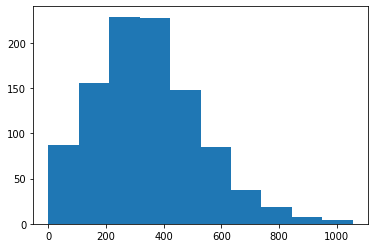

In [663]:
hist([env.chronics_handler.data._generate_maintenance().sum() for _ in range(1000)])

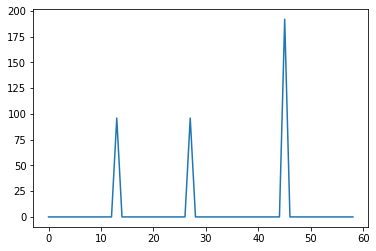

In [670]:
# Can a line be maintained twice? Yes
plot(env.chronics_handler.data.maintenance.sum(0))

In [671]:
env.chronics_handler.data.maintenance.sum(0).argmax()

45

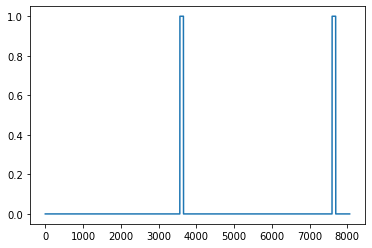

In [673]:
plot(env.chronics_handler.data.maintenance[:, 45])